<a href="https://colab.research.google.com/github/deepbairagya/Predictive_Maintenance_System/blob/main/Predictive_Maintenance_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [3]:
data = pd.read_csv('dataset.csv')

Drop non-informative columns

In [4]:
data_cleaned = data.drop(columns=['UDI','Product ID'])

Separate features and target variables

In [5]:
x = data_cleaned.drop(columns=['Machine failure'])
y = data_cleaned['Machine failure']

Define categorical and numerical columns

In [6]:
categorical_cols = ['Type']
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                  'Torque [Nm]', 'Tool wear [min]']

Preprocessing pipelines for numerical and categorical data

In [7]:
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())  # Normalize numerical features
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first'))  # One-hot encode categorical features
])

Combine preprocessing steps

In [8]:
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Apply preprocessing
x_preprocessed = preprocessor.fit_transform(x)

Convert to DataFrame for EDA

In [9]:
data_exploration = pd.DataFrame(
    x_preprocessed,
    columns=preprocessor.get_feature_names_out()
)
data_exploration['Machine failure'] = y.reset_index(drop=True)

EDA: Correlation heatmap

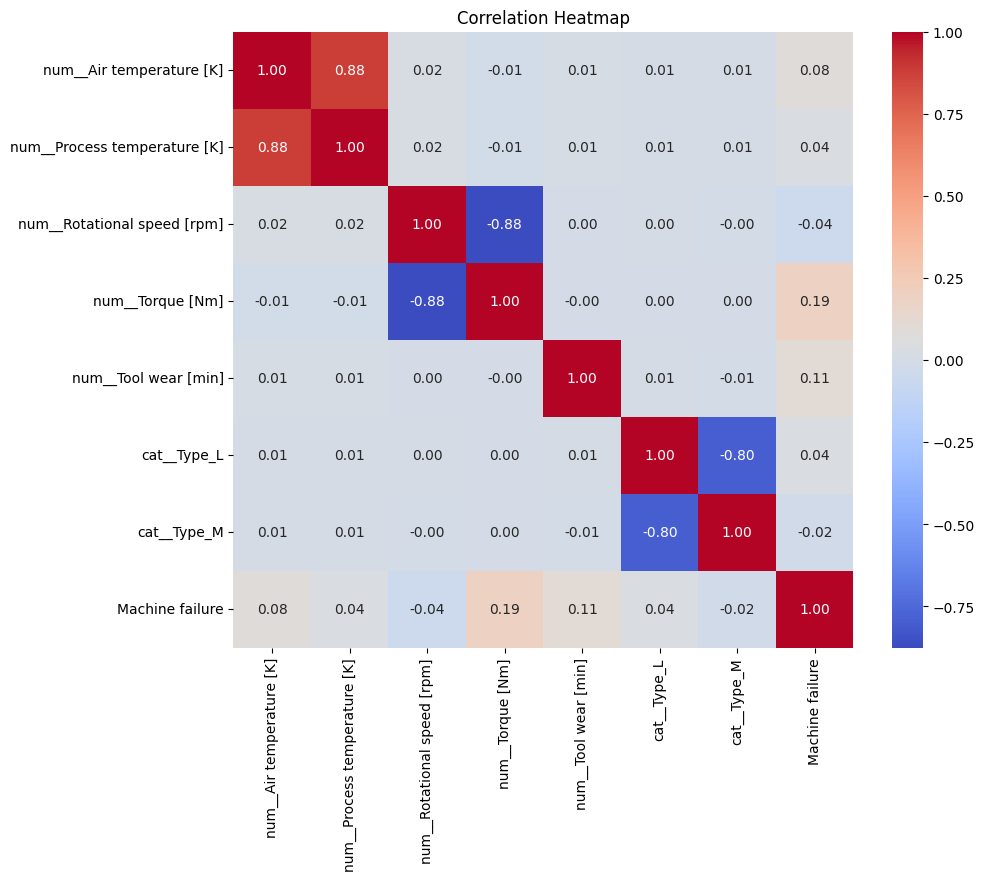

In [10]:
correlation_matrix = data_exploration.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

EDA: Numerical feature distributions

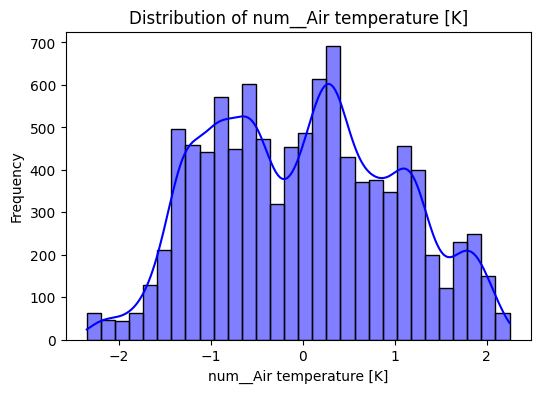

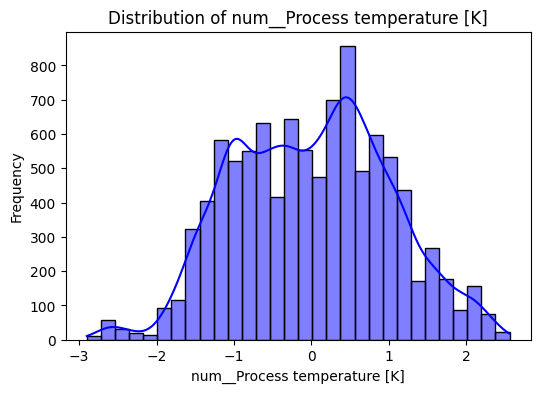

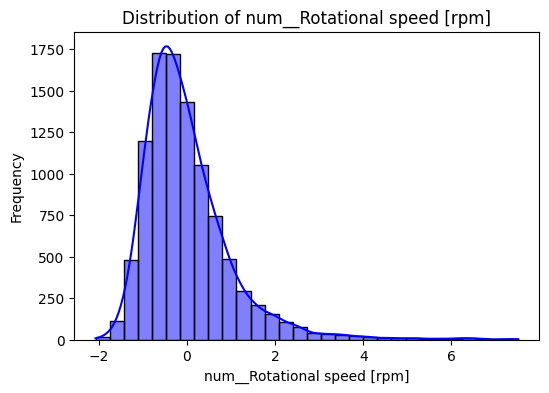

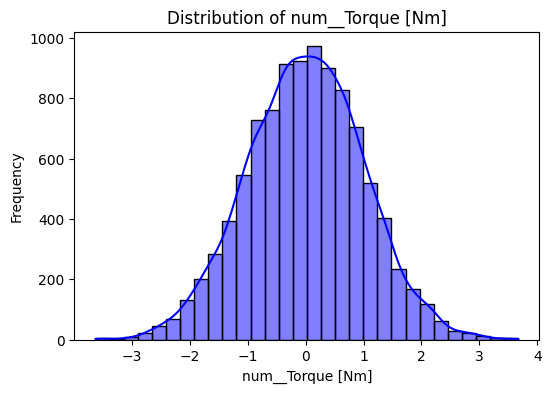

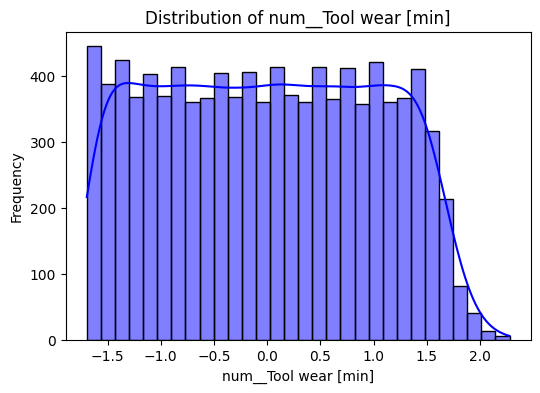

In [11]:
for feature in preprocessor.get_feature_names_out()[:5]:
    plt.figure(figsize=(6, 4))
    sns.histplot(data_exploration[feature], kde=True, bins=30, color="blue")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

EDA: Machine failure rate

<ipython-input-12-a9e4f962e310>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts, palette="viridis")


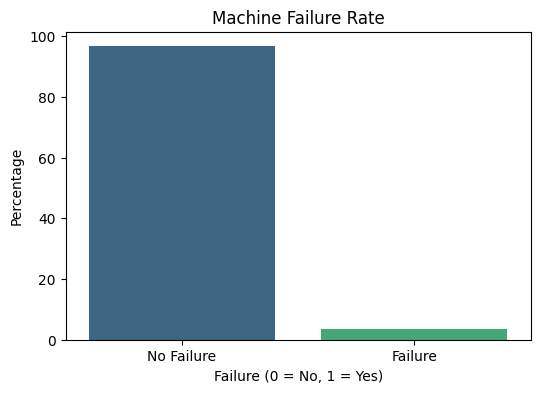

In [12]:
failure_counts = y.value_counts(normalize=True) * 100
plt.figure(figsize=(6, 4))
sns.barplot(x=failure_counts.index, y=failure_counts, palette="viridis")
plt.title("Machine Failure Rate")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Percentage")
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.show()


Addressing imbalance using SMOTE

In [13]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_preprocessed, y)


Train-test split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)


Model training: Random Forest

In [15]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

Predictions

In [16]:
y_pred = model.predict(x_test)

Evaluation

In [17]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[1894   40]
 [  19 1912]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      1934
           1       0.98      0.99      0.98      1931

    accuracy                           0.98      3865
   macro avg       0.98      0.98      0.98      3865
weighted avg       0.98      0.98      0.98      3865

Accuracy Score: 0.9847347994825356


Feature importance

<ipython-input-18-ea93846f0c4c>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=features, palette="viridis")


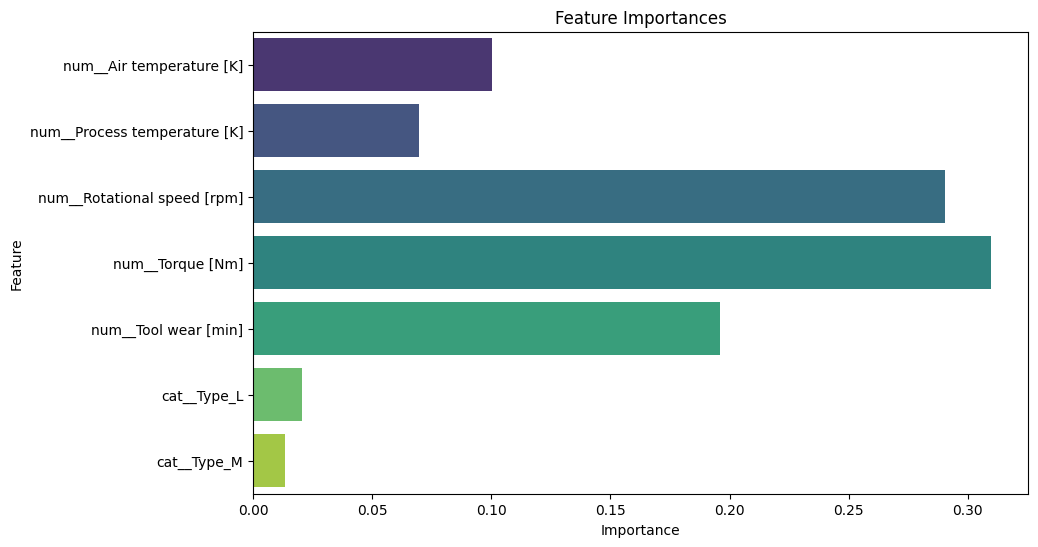

In [18]:
feature_importances = model.feature_importances_
features = preprocessor.get_feature_names_out()
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features, palette="viridis")
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
